# To discover correlations after to apply a series of transformations to index under certain frequencies 

In [19]:
import pandas as pd
import numpy as np 
import seaborn as sns

In [20]:
series = pd.read_csv('../Data/Preprocessed/HUPA0027P.csv', sep=';')['glucose'][:3500]

In [21]:
series

0       112.000000
1       105.000000
2        98.000000
3        91.000000
4        91.000000
           ...    
3495    141.000000
3496    138.000000
3497    135.000000
3498    132.000000
3499    130.666667
Name: glucose, Length: 3500, dtype: float64

In [22]:
new_data = {}
frequencies = [0.0005, 0.00069, 0.000611, 0.0011, 0.0034]
days_freq = {0.00069:5, 0.000611:5.6, 0.0005:7, 0.0011:3, 0.0034:1}
for f_i in frequencies:
    c_i = 2 * np.pi * f_i * series.index
    sin_c_i = np.sin(c_i)
    cos_ci = np.cos(c_i)
    new_data[f'f_{days_freq[f_i]}_days_cos'] = cos_ci
    new_data[f'f_{days_freq[f_i]}_days_sen'] = sin_c_i
new_data['glucose'] = series.values
    

In [23]:
data_transformed = pd.DataFrame(new_data)
corr_matrix = data_transformed.corr(numeric_only=True)


In [24]:
corr_matrix['glucose'].sort_values(ascending=False)

glucose           1.000000
f_7_days_cos      0.143065
f_7_days_sen      0.129252
f_5.6_days_sen    0.099126
f_3_days_cos      0.070687
f_3_days_sen      0.010738
f_1_days_cos     -0.054125
f_1_days_sen     -0.105207
f_5_days_cos     -0.225522
f_5_days_sen     -0.243952
f_5.6_days_cos   -0.269428
Name: glucose, dtype: float64

<Axes: >

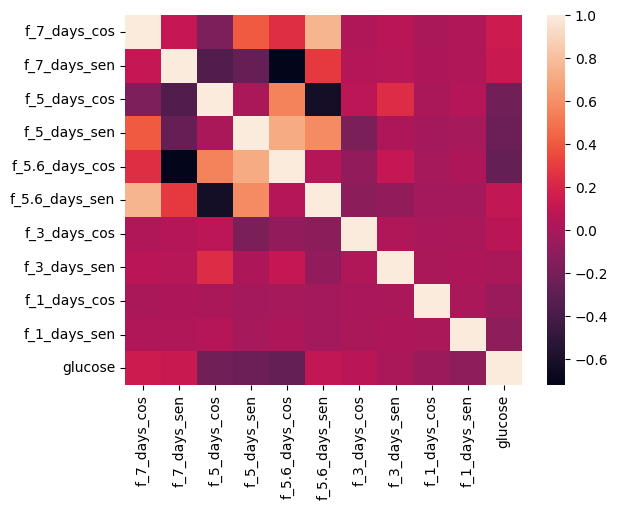

In [25]:
sns.heatmap(corr_matrix)

## Test it 


In [26]:
import sys
import os

project_root = os.path.abspath("..") 
sys.path.append(project_root)

from scripts.window_regressor import Window_Regressor_Sequence_to_scalar, Window_Regressor_Postional_Frequentist_Encoding

In [27]:
transfomer = Window_Regressor_Postional_Frequentist_Encoding(time_series_data=series, window_size=48, horizon=12, freq_to_compute=10)

In [28]:
data_created = transfomer.create_data_frame()
corr_matrix = data_created.corr()
corr_matrix['glucose'].sort_values(ascending = False)

glucose                     1.000000
f_1.7403732538223267_sin    0.362611
f_1.8458046913146973_cos    0.356997
f_1.7915390729904175_cos    0.294107
f_1.7915390729904175_sin    0.251218
f_1.450410008430481_sin     0.216578
f_6.760127067565918_sin     0.170145
f_7.60363245010376_cos      0.169601
f_6.760127067565918_cos     0.105516
f_1.7403732538223267_cos    0.087649
f_1.416690707206726_sin     0.056478
f_1.8458046913146973_sin    0.035633
f_3.5815696716308594_cos    0.023867
f_3.5815696716308594_sin    0.021307
f_8.687647819519043_cos     0.015040
f_7.60363245010376_sin     -0.047196
f_10.132139205932617_sin   -0.129507
f_10.132139205932617_cos   -0.194655
f_1.450410008430481_cos    -0.197196
f_8.687647819519043_sin    -0.201147
f_1.416690707206726_cos    -0.271922
Name: glucose, dtype: float64

In [29]:
data_to_train = transfomer.generated_data_set
data_to_train.shape

(3441, 1009)

In [31]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression, ElasticNet
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [32]:
data_simple_linear_regression = Window_Regressor_Sequence_to_scalar(time_series_data=series, window_size=12, horizon=12).generate_data_set().values
X_linear, y_linear = data_simple_linear_regression[:, :-1], data_simple_linear_regression[:, -1]
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(X_linear, y_linear, test_size=0.2, shuffle=False) 

In [33]:
X = data_to_train.values[:, :-1]
y = data_to_train.values[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [34]:
model_simple_linear = LinearRegression()
model_simple_linear.fit(X_train_linear, y_train_linear)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=500))
])

# Grid de hiperparámetros recomendado
param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10],        # fuerza de regularización
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]     # mezcla L1/L2
}

# Búsqueda de hiperparámetros
search = GridSearchCV(
    pipe,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Mejores parámetros:", search.best_params_)

# Predicciones
y_pred = search.predict(X_test)

Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_5311_62ef9a87acca4ca7a5069a193d9bdd51_aeb06f5f5cf343628042380c3c5894ba for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-5311-w4ebhvht for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource 

Mejores parámetros: {'model__alpha': 1, 'model__l1_ratio': 0.9}


In [36]:
y_pred_linear = model_simple_linear.predict(X_test_linear)

mse_linear = mean_squared_error(y_test_linear, y_pred_linear)
mae_linear = mean_absolute_error(y_test_linear, y_pred_linear)
mape_linear = mean_absolute_percentage_error(y_test_linear, y_pred_linear)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'MAE : {mae}')
print(f'MSE : {mse}')
print(f'MAPE : {mape}')
print()
print(f'MAE_linear : {mae_linear}')
print(f'MSE_linear : {mse_linear}')
print(f'MAPE linear : {mape_linear}')

MAE : 22.82246483128505
MSE : 682.9210592130453
MAPE : 0.2997537208676655

MAE_linear : 15.5026607735878
MSE_linear : 355.83697769167486
MAPE linear : 0.19716686598995856


Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-5311-ga_fl4n0 for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-5311-4yieuoa7 for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-5311-oco7rje9 for automatic cleanup

In [ ]:
print(y_test_linear.shape)
print(y_test.shape)

(454,)
(447,)


Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-9820-_6jxah9m for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-9820-7uypn918 for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-9820-qzaj40y1 for automatic cleanup